## 1) Import Lib

In [23]:
from pathlib import Path
import warnings

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

## 2) Data

In [24]:
PROJECT_ROOT = Path(r"D:/Study/DATN/hand_gesture_windows_control")

DATA_DIR = PROJECT_ROOT.joinpath("data", "processed", "static")
MODEL_DIR = PROJECT_ROOT.joinpath("models", "checkpoints")
REPORT_DIR = PROJECT_ROOT.joinpath("models", "reports", "model_comparison_ipynb")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR.joinpath("train_static_v1.csv")
VAL_CSV = DATA_DIR.joinpath("val_static_v1.csv")
TEST_CSV = DATA_DIR.joinpath("test_static_v1.csv")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)

PROJECT_ROOT = D:\Study\DATN\hand_gesture_windows_control
TRAIN_CSV = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\train_static_v1.csv
VAL_CSV   = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\val_static_v1.csv
TEST_CSV  = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\test_static_v1.csv


## 2. Load dữ liệu

In [25]:
FEATURE_COLS = [f"f{i}" for i in range(63)]

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df["label"].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df["label"].values

labels = sorted(set(y_train) | set(y_val) | set(y_test))

print("Train:", X_train.shape, len(y_train))
print("Val:  ", X_val.shape, len(y_val))
print("Test: ", X_test.shape, len(y_test))
print("Labels:", labels)

Train: (2425, 63) 2425
Val:   (830, 63) 830
Test:  (851, 63) 851
Labels: ['fist', 'no_gesture', 'open_palm', 'pinch', 'point']


In [26]:
X_train[:1]

array([[ 0.        ,  0.        ,  0.        , -0.17889526, -0.08061599,
        -0.03870525, -0.34192833, -0.37298369, -0.04768515, -0.4085187 ,
        -0.63542175, -0.06600151, -0.43489689, -0.85301846, -0.07523307,
        -0.26030904, -0.7398724 ,  0.04131817, -0.32479832, -0.9281792 ,
        -0.04616209, -0.2983526 , -0.70436138, -0.10739975, -0.25641474,
        -0.49527523, -0.13280408, -0.15123761, -0.78122056,  0.02394647,
        -0.21900167, -0.97361797, -0.06408107, -0.19447821, -0.68342984,
        -0.09579583, -0.15198088, -0.46513748, -0.09030399, -0.02685988,
        -0.7749182 , -0.0107263 , -0.09634602, -0.97444093, -0.10260185,
        -0.08695573, -0.67963016, -0.08634921, -0.05708436, -0.46494997,
        -0.0452048 ,  0.10901178, -0.72439402, -0.04988238,  0.03497037,
        -0.90598774, -0.11632267,  0.01871683, -0.69728148, -0.09516854,
         0.03629063, -0.52095473, -0.05747838]])

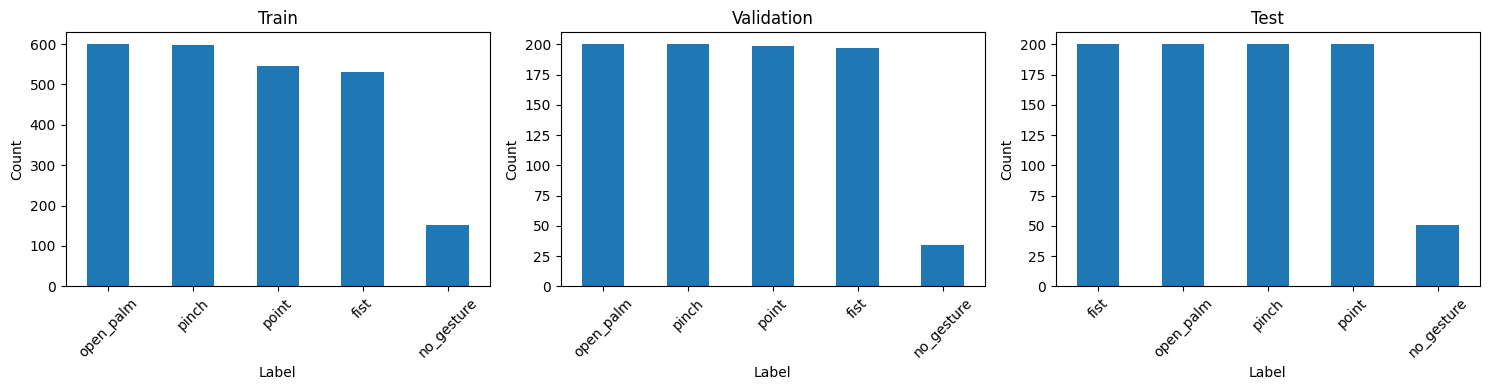

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_df["label"].value_counts().plot(kind="bar", ax=axes[0], title="Train")
val_df["label"].value_counts().plot(kind="bar", ax=axes[1], title="Validation")
test_df["label"].value_counts().plot(kind="bar", ax=axes[2], title="Test")

for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [28]:
display(train_df["label"].value_counts().rename("train_count").to_frame())
display(val_df["label"].value_counts().rename("val_count").to_frame())
display(test_df["label"].value_counts().rename("test_count").to_frame())

,train_count
label,
open_palm,599
pinch,597
point,545
fist,531
no_gesture,153


,val_count
label,
open_palm,200
pinch,200
point,199
fist,197
no_gesture,34


,test_count
label,
fist,200
open_palm,200
pinch,200
point,200
no_gesture,51


## 3. Train Model (SVM, logistic reg, KNN, Random fr, mlp)

In [29]:
models = {
    "svm_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=True))
    ]),
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "knn": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance"
        ))
    ]),
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    # "mlp": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("clf", MLPClassifier(
    #         hidden_layer_sizes=(128, 64),
    #         activation="relu",
    #         solver="adam",
    #         alpha=1e-4,
    #         batch_size=64,
    #         learning_rate_init=1e-3,
    #         max_iter=300,
    #         early_stopping=True,
    #         validation_fraction=0.1,
    #         random_state=42
    #     ))
    # ]),
}

list(models.keys())

['svm_rbf', 'logistic_regression', 'knn', 'random_forest']

In [30]:
# hàm đánh giá model

def evaluate_model(model_name, model, X_val, y_val, X_test, y_test, labels):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    val_report = classification_report(y_val, y_val_pred, labels=labels, digits=4, zero_division=0)
    test_report = classification_report(y_test, y_test_pred, labels=labels, digits=4, zero_division=0)

    val_cm = confusion_matrix(y_val, y_val_pred, labels=labels)
    test_cm = confusion_matrix(y_test, y_test_pred, labels=labels)

    return {
        "model_name": model_name,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_report": val_report,
        "test_report": test_report,
        "val_cm": val_cm,
        "test_cm": test_cm,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }

In [31]:
results = {}
summary_rows = []

for model_name, model in models.items():
    print("=" * 70)
    print("Training:", model_name)

    model.fit(X_train, y_train)

    result = evaluate_model(model_name, model, X_val, y_val, X_test, y_test, labels)
    results[model_name] = {
        "model": model,
        **result
    }

    summary_rows.append({
        "model": model_name,
        "val_accuracy": round(result["val_acc"], 6),
        "test_accuracy": round(result["test_acc"], 6),
    })

    print("Validation Accuracy:", round(result["val_acc"], 4))
    print("Test Accuracy:", round(result["test_acc"], 4))

Training: svm_rbf
Validation Accuracy: 0.9747
Test Accuracy: 0.973
Training: logistic_regression
Validation Accuracy: 0.988
Test Accuracy: 0.9683
Training: knn
Validation Accuracy: 0.9036
Test Accuracy: 0.9318
Training: random_forest
Validation Accuracy: 0.9651
Test Accuracy: 0.9671


## 4. Kết quả train

In [32]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["test_accuracy", "val_accuracy"], ascending=False
).reset_index(drop=True)

summary_df

,model,val_accuracy,test_accuracy
0,svm_rbf,0.974699,0.972973
1,logistic_regression,0.987952,0.968273
2,random_forest,0.965060,0.967098
3,knn,0.903614,0.931845


In [33]:
summary_df.to_csv(REPORT_DIR.joinpath("model_comparison_summary.csv"), index=False)
print("Model comparison summary saved to:", REPORT_DIR.joinpath("model_comparison_summary.csv"))

Model comparison summary saved to: D:\Study\DATN\hand_gesture_windows_control\models\reports\model_comparison_ipynb\model_comparison_summary.csv


## 5. Classification report từng model

### 5.1) SVM RBF

In [34]:
def classification_report(model_name):
    print("[VALIDATION REPORT]")
    print(results[model_name]["val_report"])

    print("[TEST REPORT]")
    print(results[model_name]["test_report"])

def confusion_matrix(model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["val_cm"],
        display_labels=labels
    ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{model_name} - Validation")

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["test_cm"],
        display_labels=labels
    ).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    plt.show()

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9849    0.9949    0.9899       197
  no_gesture     0.9189    1.0000    0.9577        34
   open_palm     0.9346    1.0000    0.9662       200
       pinch     0.9947    0.9300    0.9612       200
       point     1.0000    0.9698    0.9847       199

    accuracy                         0.9747       830
   macro avg     0.9666    0.9790    0.9720       830
weighted avg     0.9760    0.9747    0.9747       830

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9259    1.0000    0.9615       200
  no_gesture     1.0000    0.6863    0.8140        51
   open_palm     0.9898    0.9750    0.9824       200
       pinch     0.9754    0.9900    0.9826       200
       point     1.0000    1.0000    1.0000       200

    accuracy                         0.9730       851
   macro avg     0.9782    0.9303    0.9481       851
weighted avg     0.9744    0.9730    0.9716

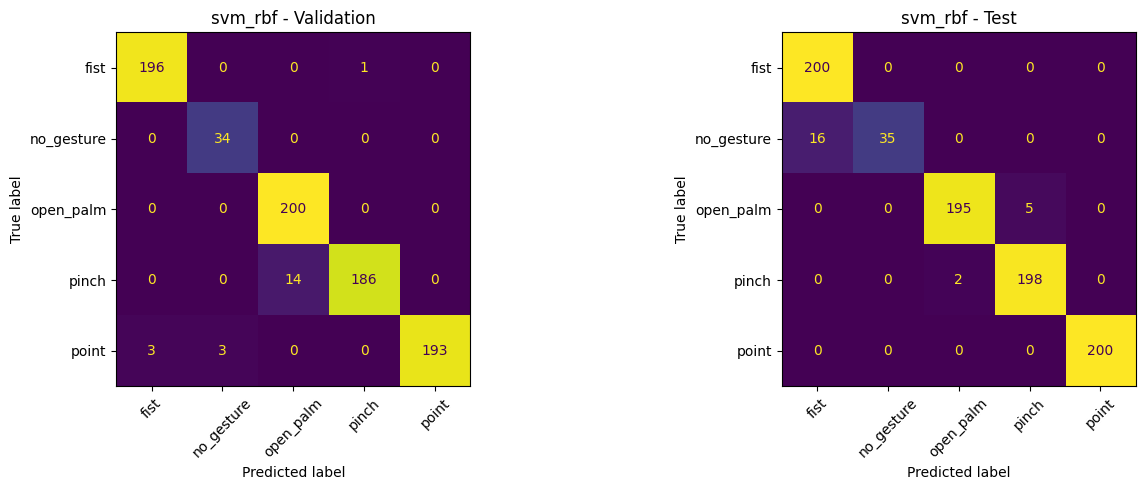

In [35]:
classification_report("svm_rbf")
confusion_matrix("svm_rbf")

### 5.2) Model logistic_regression

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9949    0.9848    0.9898       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.9709    1.0000    0.9852       200
       pinch     0.9949    0.9700    0.9823       200
       point     0.9900    0.9950    0.9925       199

    accuracy                         0.9880       830
   macro avg     0.9901    0.9899    0.9900       830
weighted avg     0.9881    0.9880    0.9879       830

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9519    0.9900    0.9706       200
  no_gesture     1.0000    0.5882    0.7407        51
   open_palm     1.0000    0.9800    0.9899       200
       pinch     0.9804    1.0000    0.9901       200
       point     0.9390    1.0000    0.9685       200

    accuracy                         0.9683       851
   macro avg     0.9743    0.9116    0.9320       851
weighted avg     0.9697    0.9683    0.9655

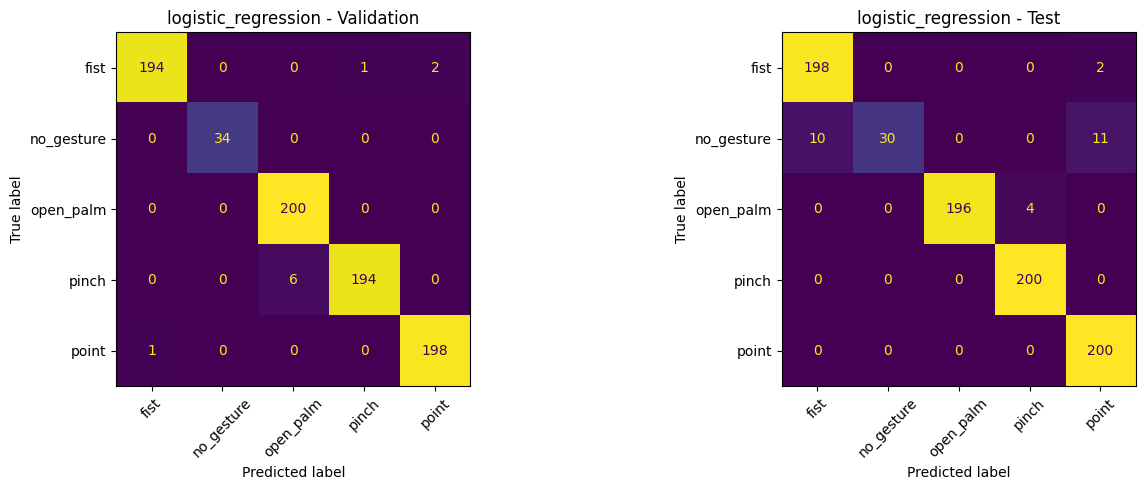

In [36]:
classification_report("logistic_regression")
confusion_matrix("logistic_regression")

### 5.3) Model KNN

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9800    0.9949    0.9874       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.7788    0.8800    0.8263       200
       pinch     0.8571    0.7500    0.8000       200
       point     0.9949    0.9749    0.9848       199

    accuracy                         0.9036       830
   macro avg     0.9222    0.9200    0.9197       830
weighted avg     0.9063    0.9036    0.9033       830

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9238    0.9700    0.9463       200
  no_gesture     1.0000    0.4902    0.6579        51
   open_palm     0.9061    0.9650    0.9346       200
       pinch     0.8916    0.9050    0.8983       200
       point     1.0000    1.0000    1.0000       200

    accuracy                         0.9318       851
   macro avg     0.9443    0.8660    0.8874       851
weighted avg     0.9346    0.9318    0.9276

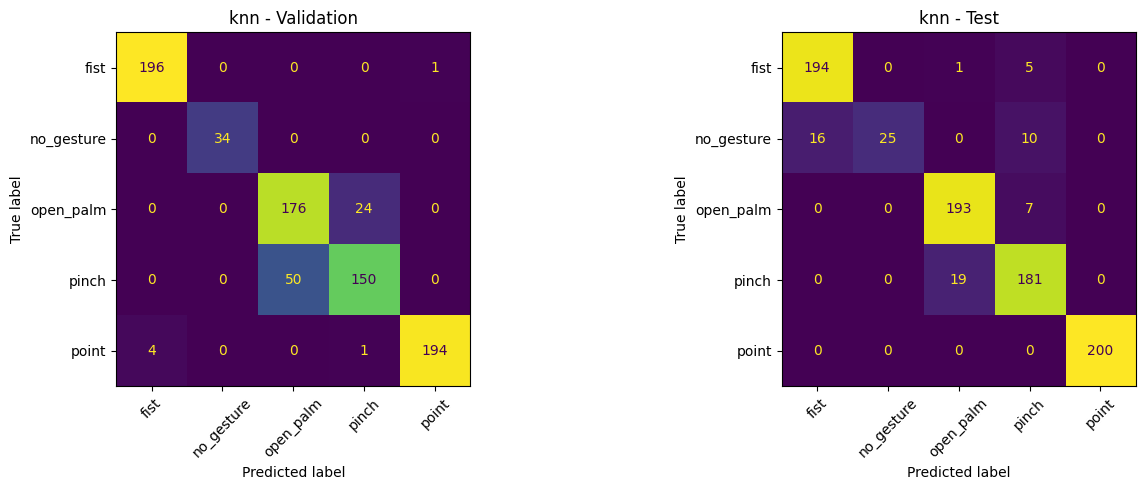

In [37]:
classification_report("knn")
confusion_matrix("knn")

### 5.4) Model random forest

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9701    0.9898    0.9799       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.9198    0.9750    0.9466       200
       pinch     0.9735    0.9200    0.9460       200
       point     0.9948    0.9698    0.9822       199

    accuracy                         0.9651       830
   macro avg     0.9717    0.9709    0.9709       830
weighted avg     0.9660    0.9651    0.9651       830

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9132    1.0000    0.9547       200
  no_gesture     1.0000    0.6275    0.7711        51
   open_palm     0.9948    0.9600    0.9771       200
       pinch     0.9614    0.9950    0.9779       200
       point     1.0000    1.0000    1.0000       200

    accuracy                         0.9671       851
   macro avg     0.9739    0.9165    0.9361       851
weighted avg     0.9693    0.9671    0.9650

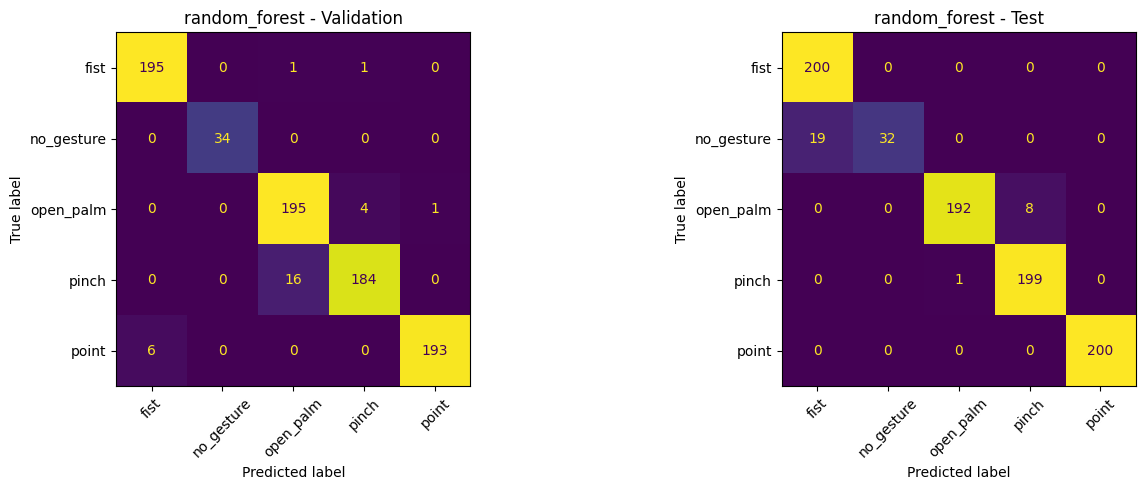

In [38]:
classification_report("random_forest")
confusion_matrix("random_forest")

## 6. Lưu model và báo cáo

In [39]:

print(labels)

['fist', 'no_gesture', 'open_palm', 'pinch', 'point']


In [ ]:
# Save best final model for deployment
BEST_MODEL_NAME = 'svm_rbf'
BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'checkpoints'/ 'static_hand_gesture_model_svm_rbf.joblib'
BEST_META_PATH = PROJECT_ROOT / 'models' / 'reports' / 'static_hand_gesture_model_svm_rbf_meta.json'

best_model = results[BEST_MODEL_NAME]['model']

import joblib
joblib.dump(best_model, BEST_MODEL_PATH)

import json
meta = {
    'best_model': BEST_MODEL_NAME,
    'labels': labels,
    'val_accuracy': float(results[BEST_MODEL_NAME]['val_acc']),
    'test_accuracy': float(results[BEST_MODEL_NAME]['test_acc']),
    'feature_columns': FEATURE_COLS,
    'note': 'Chosen by highest test accuracy and better generalization than logistic_regression'
}

BEST_META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved model to:', BEST_MODEL_PATH)
print('Saved metadata to:', BEST_META_PATH)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\static_hand_gesture_model_svm_rbf.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\static_hand_gesture_model_svm_rbf_meta.json
